# Function 4 Analysis - Week 13

1. **Function description (unchanged):**  
Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

## Week 12 evaluated point and assessment
- **Evaluated point:** `(0.398482, 0.382027, 0.391800, 0.372791)` -> **y = 0.098871**
- **Assessment:** **Poor point** compared with the incumbent peak.
- **Why:** Although positive, it is far below the best basin value and suggests the move did not stay on the strongest local ridge.

## High-level recommendation for final week
Given this is the final week, use **focused local exploitation** around the incumbent best basin with tight local bounds and anti-duplicate spacing.


In [11]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_4")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.100000, 0.400000, 0.400000, 0.050000]])
y_new_point_week_1 = np.array([-11.551402216263181])
X_new_point_week_2 = np.array([[0.412000, 0.448200, 0.386300, 0.439500]])
y_new_point_week_2 = np.array([-0.05797573871593498])
X_new_point_week_3 = np.array([[0.426200, 0.452700, 0.391900, 0.429300]])
y_new_point_week_3 = np.array([-0.013999616551390925])
X_new_point_week_4 = np.array([[0.430000, 0.455200, 0.393800, 0.427600]])
y_new_point_week_4 = np.array([-0.09998342305973962])
X_new_point_week_5 = np.array([[0.430300, 0.359300, 0.351800, 0.383700]])
y_new_point_week_5 = np.array([0.5518426262369016])
X_new_point_week_6 = np.array([[0.421100, 0.389600, 0.370500, 0.393100]])
y_new_point_week_6 = np.array([0.37109387744135747])
X_new_point_week_7 = np.array([[0.440000, 0.390769, 0.330000, 0.410000]])
y_new_point_week_7 = np.array([-0.05018491923068735])
X_new_point_week_8 = np.array([[0.436923, 0.340000, 0.380000, 0.407241]])
y_new_point_week_8 = np.array([0.26196137938032793])
X_new_point_week_9 = np.array([[0.425755, 0.309300, 0.301800, 0.433700]])
y_new_point_week_9 = np.array([-1.36678705398441])
X_new_point_week_10 = np.array([[0.443936, 0.354755, 0.401800, 0.415518]])
y_new_point_week_10 = np.array([0.3215923310779307])
X_new_point_week_11 = np.array([[0.446799, 0.409600, 0.351800, 0.376427]])
y_new_point_week_11 = np.array([0.18884115871870266])
X_new_point_week_12 = np.array([[0.398482, 0.382027, 0.391800, 0.372791]])
y_new_point_week_12 = np.array([0.0988706442514808])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
    X_new_point_week_11,
    X_new_point_week_12,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
    y_new_point_week_11,
    y_new_point_week_12,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"])
df["y"] = y

# Display original and y-sorted DataFrames side by side
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633
5,0.801303,0.500231,0.706645,0.195103,-15.487083
6,0.247708,0.060445,0.042186,0.441324,-12.681685
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049235
9,0.626071,0.586751,0.438806,0.778858,-12.741766


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.430300,0.359300,0.351800,0.383700,0.551843,0.381275
1,0.421100,0.389600,0.370500,0.393100,0.371094,0.393575
2,0.443936,0.354755,0.401800,0.415518,0.321592,0.404002
3,0.436923,0.340000,0.380000,0.407241,0.261961,0.391041
4,0.446799,0.409600,0.351800,0.376427,0.188841,0.396157
5,0.398482,0.382027,0.391800,0.372791,0.098871,0.386275
6,0.426200,0.452700,0.391900,0.429300,-0.014000,0.425025
7,0.440000,0.390769,0.330000,0.410000,-0.050185,0.392692
8,0.412000,0.448200,0.386300,0.439500,-0.057976,0.421500
9,0.430000,0.455200,0.393800,0.427600,-0.099983,0.426650


## Weekly Optimization Progress Summary

Overview of all 12 completed weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 12 update:** `(0.398482, 0.382027, 0.391800, 0.372791)` → **≈0.0989** (not a new maximum).


In [12]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8,
            X_new_point_week_9]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8,
            y_new_point_week_9]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 110)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 110)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,y,Running_Max,Status,Improvement
0,1,0.100000,0.400000,0.4000,0.050000,-11.551402,-11.551402,✓ NEW MAX,+1.000000
1,2,0.412000,0.448200,0.3863,0.439500,-0.057976,-0.057976,✓ NEW MAX,+11.493426
2,3,0.426200,0.452700,0.3919,0.429300,-0.014000,-0.014000,✓ NEW MAX,+0.043976
3,4,0.430000,0.455200,0.3938,0.427600,-0.099983,-0.014000,✗,-
4,5,0.430300,0.359300,0.3518,0.383700,0.551843,0.551843,✓ NEW MAX,+0.565842
5,6,0.421100,0.389600,0.3705,0.393100,0.371094,0.551843,✗,-
6,7,0.440000,0.390769,0.3300,0.410000,-0.050185,0.551843,✗,-
7,8,0.436923,0.340000,0.3800,0.407241,0.261961,0.551843,✗,-
8,9,0.425755,0.309300,0.3018,0.433700,-1.366787,0.551843,✗,-



📊 Summary: 4/9 weeks achieved new max (Weeks [1, 2, 3, 5])
   Success rate: 44.4% | Final best: 0.551843


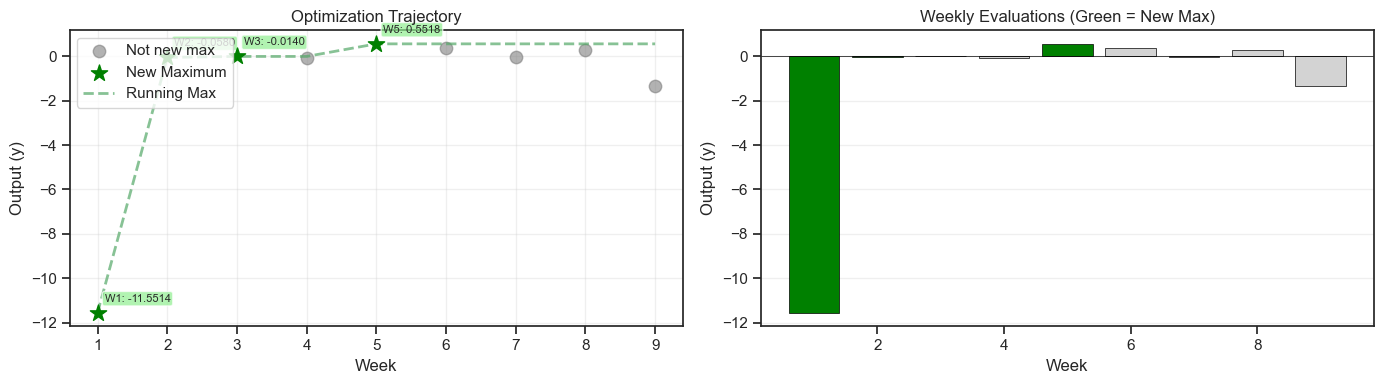

In [13]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Simplified BO with Expected Improvement (EI)

With limited evaluations remaining, we switch to a simpler local BO workflow:
1. Fit a noisy GP surrogate around the incumbent region.
2. Score local candidates using Expected Improvement (EI).
3. Select the top EI point (and a backup) under simple distance constraints.

This keeps the process transparent, local, and practical for the final two evaluations.


In [14]:
# Simplified local BO using Expected Improvement (EI)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm

# Current best (incumbent)
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx]
best_x1, best_x2, best_x3, best_x4 = best_point["x1"], best_point["x2"], best_point["x3"], best_point["x4"]
best_y = float(best_point["y"])

print(f"Current best: ({best_x1:.6f}, {best_x2:.6f}, {best_x3:.6f}, {best_x4:.6f}) = {best_y:.6f}")

# Tight local region around incumbent (more exploitative for final evaluations)
rad_x1, rad_x2, rad_x3, rad_x4 = 0.04, 0.04, 0.03, 0.03
sr_x1_min, sr_x1_max = max(0, best_x1 - rad_x1), min(1, best_x1 + rad_x1)
sr_x2_min, sr_x2_max = max(0, best_x2 - rad_x2), min(1, best_x2 + rad_x2)
sr_x3_min, sr_x3_max = max(0, best_x3 - rad_x3), min(1, best_x3 + rad_x3)
sr_x4_min, sr_x4_max = max(0, best_x4 - rad_x4), min(1, best_x4 + rad_x4)

print("Local search bounds:")
print(f"  x1 in [{sr_x1_min:.3f}, {sr_x1_max:.3f}]")
print(f"  x2 in [{sr_x2_min:.3f}, {sr_x2_max:.3f}]")
print(f"  x3 in [{sr_x3_min:.3f}, {sr_x3_max:.3f}]")
print(f"  x4 in [{sr_x4_min:.3f}, {sr_x4_max:.3f}]\n")

# Fit noisy GP surrogate
kernel = (
    ConstantKernel(1.0, (1e-2, 100.0))
    * Matern(length_scale=[0.1, 0.1, 0.1, 0.1], length_scale_bounds=(0.01, 0.5), nu=2.5)
    + WhiteKernel(noise_level=0.04, noise_level_bounds=(1e-4, 0.5))
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=12, random_state=42)
gp.fit(X, y)
print(f"GP fitted. Kernel: {gp.kernel_}\n")

# Candidate grid in local box
grid_res = 12
grid_x1 = np.linspace(sr_x1_min, sr_x1_max, grid_res)
grid_x2 = np.linspace(sr_x2_min, sr_x2_max, grid_res)
grid_x3 = np.linspace(sr_x3_min, sr_x3_max, grid_res)
grid_x4 = np.linspace(sr_x4_min, sr_x4_max, grid_res)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3, grid_x4)).reshape(4, -1).T

mu, sigma = gp.predict(mesh, return_std=True)
sigma = np.maximum(sigma, 1e-9)

# Expected Improvement (smaller xi -> more exploitative)
xi = 0.002
improvement = mu - best_y - xi
Z = improvement / sigma
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

candidates = pd.DataFrame(mesh, columns=["x1", "x2", "x3", "x4"])
candidates["mu"] = mu
candidates["sigma"] = sigma
candidates["ei"] = ei

# Keep points different from existing data and local to incumbent
obs = df[["x1", "x2", "x3", "x4"]].values
cand = candidates[["x1", "x2", "x3", "x4"]].values
pairwise = np.sqrt(((cand[:, None, :] - obs[None, :, :]) ** 2).sum(axis=2))
candidates["min_dist_obs"] = pairwise.min(axis=1)

best_vec = np.array([best_x1, best_x2, best_x3, best_x4])
candidates["dist_best"] = np.linalg.norm(cand - best_vec, axis=1)

min_dist_obs = 0.008
max_step_from_best = 0.06
candidates = candidates[(candidates["min_dist_obs"] >= min_dist_obs) & (candidates["dist_best"] <= max_step_from_best)].copy()

# Rank by EI (then mu), with distance tie-break favoring closer exploitative steps
ei_top = candidates.sort_values(["ei", "mu", "dist_best"], ascending=[False, False, True]).head(10).copy()

if len(ei_top) == 0:
    print("No feasible EI candidates found. Consider relaxing constraints.")
else:
    rec = ei_top.iloc[0]
    backup = ei_top.iloc[1] if len(ei_top) > 1 else None

    print("Top EI candidates:")
    display(ei_top[["x1", "x2", "x3", "x4", "mu", "sigma", "ei", "dist_best"]])

    print("\n" + "=" * 60)
    print("SIMPLIFIED EI-BO RECOMMENDATION")
    print("=" * 60)
    print(f"Primary: ({rec['x1']:.6f}, {rec['x2']:.6f}, {rec['x3']:.6f}, {rec['x4']:.6f})")
    print(f"Primary predicted: mu={rec['mu']:.4f}, sigma={rec['sigma']:.4f}, EI={rec['ei']:.6f}")
    print(f"Submission format: {rec['x1']:.6f}-{rec['x2']:.6f}-{rec['x3']:.6f}-{rec['x4']:.6f}")

    if backup is not None:
        print(f"\nBackup: ({backup['x1']:.6f}, {backup['x2']:.6f}, {backup['x3']:.6f}, {backup['x4']:.6f})")
        print(f"Backup predicted: mu={backup['mu']:.4f}, sigma={backup['sigma']:.4f}, EI={backup['ei']:.6f}")
        print(f"Backup format: {backup['x1']:.6f}-{backup['x2']:.6f}-{backup['x3']:.6f}-{backup['x4']:.6f}")


Current best: (0.430300, 0.359300, 0.351800, 0.383700) = 0.551843
Local search bounds:
  x1 in [0.390, 0.470]
  x2 in [0.319, 0.399]
  x3 in [0.322, 0.382]
  x4 in [0.354, 0.414]

GP fitted. Kernel: 0.84**2 * Matern(length_scale=[0.5, 0.5, 0.5, 0.5], nu=2.5) + WhiteKernel(noise_level=0.0001)

Top EI candidates:


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a bette

,x1,x2,x3,x4,mu,sigma,ei,dist_best
8317,0.455755,0.348391,0.370891,0.359155,0.474838,0.258245,0.068306,0.041640
8316,0.455755,0.348391,0.370891,0.353700,0.454352,0.277683,0.068070,0.045071
8304,0.455755,0.348391,0.365436,0.353700,0.456881,0.275237,0.068067,0.043045
6576,0.455755,0.341118,0.365436,0.353700,0.434698,0.296103,0.067991,0.045436
8305,0.455755,0.348391,0.365436,0.359155,0.475392,0.255944,0.067641,0.039438
6588,0.455755,0.341118,0.370891,0.353700,0.431357,0.298248,0.067636,0.047360
8461,0.463027,0.348391,0.370891,0.359155,0.447315,0.280836,0.066739,0.046444
6720,0.463027,0.341118,0.365436,0.353700,0.406031,0.318509,0.066604,0.049876
8318,0.455755,0.348391,0.370891,0.364609,0.488094,0.240204,0.066521,0.038676
8329,0.455755,0.348391,0.376345,0.359155,0.465584,0.262587,0.066490,0.044406



SIMPLIFIED EI-BO RECOMMENDATION
Primary: (0.455755, 0.348391, 0.370891, 0.359155)
Primary predicted: mu=0.4748, sigma=0.2582, EI=0.068306
Submission format: 0.455755-0.348391-0.370891-0.359155

Backup: (0.455755, 0.348391, 0.370891, 0.353700)
Backup predicted: mu=0.4544, sigma=0.2777, EI=0.068070
Backup format: 0.455755-0.348391-0.370891-0.353700


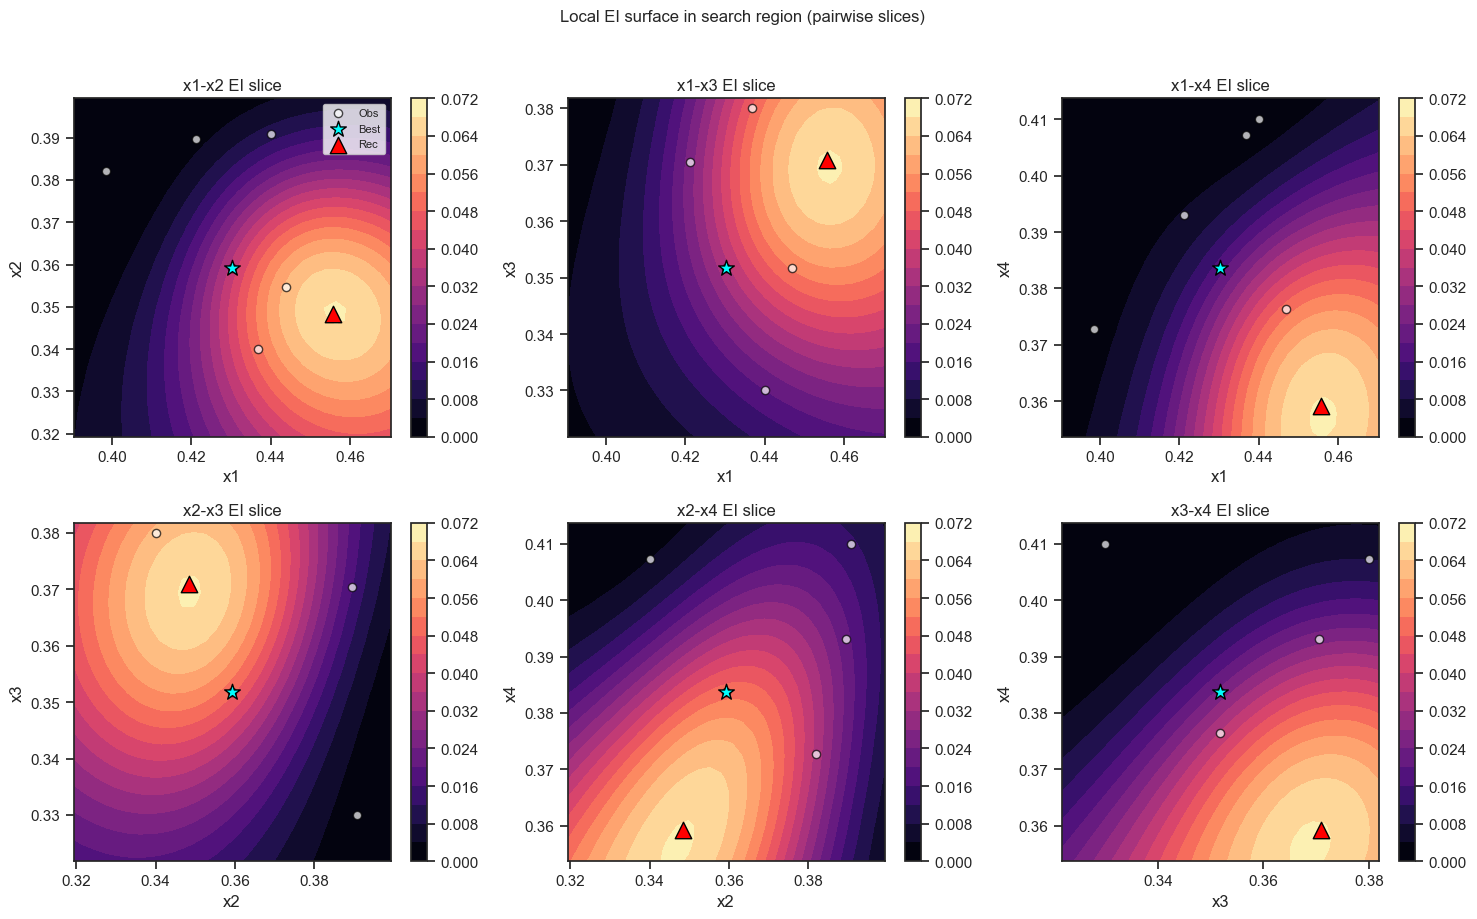

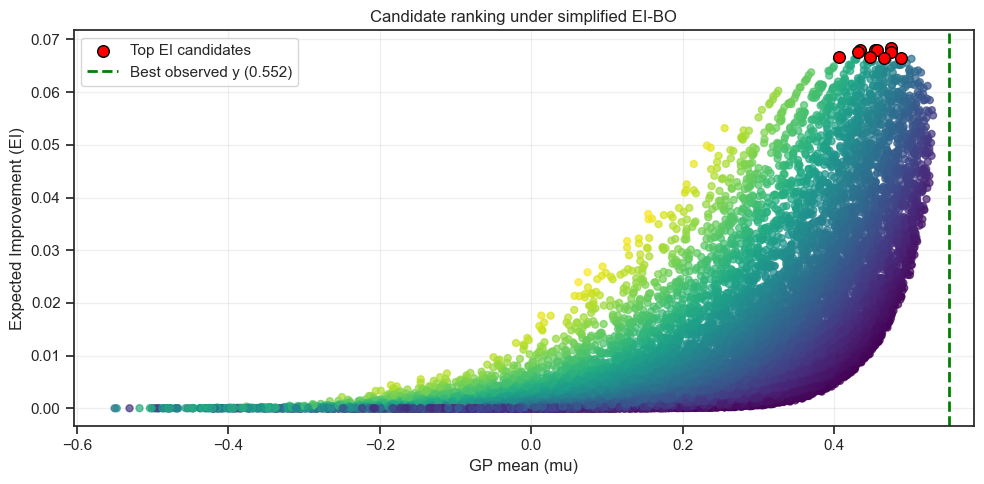

In [15]:
# Visualization: simplified EI-BO results
# =======================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

if 'rec' in globals():
    rec_x = {'x1': rec['x1'], 'x2': rec['x2'], 'x3': rec['x3'], 'x4': rec['x4']}
else:
    rec_x = {'x1': best_x1, 'x2': best_x2, 'x3': best_x3, 'x4': best_x4}

pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (0, 3, 'x1', 'x4'),
         (1, 2, 'x2', 'x3'), (1, 3, 'x2', 'x4'), (2, 3, 'x3', 'x4')]

sr_bounds = {
    'x1': (sr_x1_min, sr_x1_max),
    'x2': (sr_x2_min, sr_x2_max),
    'x3': (sr_x3_min, sr_x3_max),
    'x4': (sr_x4_min, sr_x4_max),
}

for ax_idx, (_, _, label_i, label_j) in enumerate(pairs):
    ax = axes[ax_idx]

    slice_res = 30
    xi_grid = np.linspace(sr_bounds[label_i][0], sr_bounds[label_i][1], slice_res)
    xj_grid = np.linspace(sr_bounds[label_j][0], sr_bounds[label_j][1], slice_res)
    xxi, xxj = np.meshgrid(xi_grid, xj_grid)

    slice_pts = np.zeros((slice_res * slice_res, 4))
    col_map = {'x1': 0, 'x2': 1, 'x3': 2, 'x4': 3}
    slice_pts[:, col_map[label_i]] = xxi.ravel()
    slice_pts[:, col_map[label_j]] = xxj.ravel()
    for col_name in ['x1', 'x2', 'x3', 'x4']:
        if col_name != label_i and col_name != label_j:
            slice_pts[:, col_map[col_name]] = rec_x[col_name]

    mu_slice, sigma_slice = gp.predict(slice_pts, return_std=True)
    sigma_slice = np.maximum(sigma_slice, 1e-9)
    imp_slice = mu_slice - best_y - xi
    z_slice = imp_slice / sigma_slice
    ei_slice = (imp_slice * norm.cdf(z_slice) + sigma_slice * norm.pdf(z_slice)).reshape(xxi.shape)

    im = ax.contourf(xxi, xxj, ei_slice, levels=20, cmap='magma')

    ax.scatter(df[label_i], df[label_j], c='white', edgecolor='black', s=35, alpha=0.7, label='Obs')
    ax.scatter(best_point[label_i], best_point[label_j], c='cyan', edgecolor='black', s=140, marker='*', label='Best')
    ax.scatter(rec_x[label_i], rec_x[label_j], c='red', edgecolor='black', s=140, marker='^', label='Rec')

    ax.set_xlim(sr_bounds[label_i])
    ax.set_ylim(sr_bounds[label_j])
    ax.set_xlabel(label_i)
    ax.set_ylabel(label_j)
    ax.set_title(f'{label_i}-{label_j} EI slice')
    plt.colorbar(im, ax=ax)

axes[0].legend(fontsize=8, loc='upper right')
plt.suptitle('Local EI surface in search region (pairwise slices)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Candidate summary: EI vs predicted mean
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.scatter(candidates['mu'], candidates['ei'], c=candidates['sigma'], cmap='viridis', s=25, alpha=0.7)

if 'ei_top' in globals() and len(ei_top) > 0:
    ax2.scatter(ei_top['mu'], ei_top['ei'], c='red', s=70, edgecolor='black', label='Top EI candidates')

ax2.axvline(x=best_y, color='green', linestyle='--', linewidth=2, label=f'Best observed y ({best_y:.3f})')
ax2.set_xlabel('GP mean (mu)')
ax2.set_ylabel('Expected Improvement (EI)')
ax2.set_title('Candidate ranking under simplified EI-BO')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Current best:** `0.430300-0.359300-0.351800-0.383700` (approximately 0.5518)

**Week 12 evaluated point:** `0.398482-0.382027-0.391800-0.372791` returned approximately 0.0989 (below incumbent).

**Proposed next point (submission format):** use the **Primary** EI recommendation printed above. Submission format: `0.455755-0.348391-0.370891-0.359155`

**Simplified process now used:**
1. Fit a noisy local GP around the incumbent.
2. Build a tight local candidate grid.
3. Score candidates with Expected Improvement (EI).
4. Apply simple distance constraints (avoid near-duplicates, keep steps local).
5. Take the top EI candidate, with the second-ranked EI point as backup for the final evaluation.

This removes Thompson-specific sampling complexity and gives a more direct, reproducible final-stage decision rule.
